# Optimización de Colonia de Hormigas (ACO) para Pathfinding

Este notebook implementa el algoritmo ACO para encontrar el camino más corto en un entorno de rejilla con obstáculos.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


In [11]:
class AntColonyOptimization:
    def __init__(self, start, end, obstacles, grid_size=(10, 10), num_ants=10, evaporation_rate=0.1, alpha=0.1, beta=15):
        self.start = start
        self.end = end
        self.obstacles = obstacles
        self.grid_size = grid_size
        self.num_ants = num_ants
        self.evaporation_rate = evaporation_rate
        self.alpha = alpha
        self.beta = beta
        self.pheromones = np.ones(grid_size)
        self.best_path = None

    def _get_neighbors(self, position):
        pos_x, pos_y = position
        neighbors = []
        for i in range(-1, 2):
            for j in range(-1, 2):
                new_x, new_y = pos_x + i, pos_y + j
                if (0 <= new_x < self.grid_size[0] and 0 <= new_y < self.grid_size[1] and
                        (new_x, new_y) != position and (new_x, new_y) not in self.obstacles):
                    neighbors.append((new_x, new_y))
        return neighbors

    def _select_next_position(self, position, visited):
        neighbors = self._get_neighbors(position)
        probabilities = []
        total = 0
        for neighbor in neighbors:
            if neighbor not in visited:
                pheromone = self.pheromones[neighbor[1], neighbor[0]]
                heuristic = 1 / (np.linalg.norm(np.array(neighbor) - np.array(self.end)) + 0.1)
                probabilities.append((neighbor, pheromone ** self.alpha * heuristic ** self.beta))
                total += pheromone ** self.alpha * heuristic ** self.beta
        if not probabilities:
            return None
        probabilities = [(pos, prob / total) for pos, prob in probabilities]
        selected = np.random.choice(len(probabilities), p=[prob for pos, prob in probabilities])
        return probabilities[selected][0]

    def _evaporate_pheromones(self):
        self.pheromones *= (1 - self.evaporation_rate)

    def _deposit_pheromones(self, path):
        for position in path:
            self.pheromones[position[1], position[0]] += 1

    def find_best_path(self, num_iterations):
        for _ in range(num_iterations):
            all_paths = []
            for _ in range(self.num_ants):
                current_position = self.start
                path = [current_position]
                while current_position != self.end:
                    next_position = self._select_next_position(current_position, path)
                    if next_position is None:
                        break
                    path.append(next_position)
                    current_position = next_position
                all_paths.append(path)

            # Filtrar solo los caminos que llegaron al destino
            valid_paths = [p for p in all_paths if p[-1] == self.end]

            if valid_paths:
                valid_paths.sort(key=lambda x: len(x))
                best_iteration_path = valid_paths[0]

                self._evaporate_pheromones()
                self._deposit_pheromones(best_iteration_path)

                if self.best_path is None or len(best_iteration_path) < len(self.best_path):
                    self.best_path = best_iteration_path
            else:
                # Si ninguna hormiga llega al destino, solo se evaporan las feromonas
                self._evaporate_pheromones()

    def plot(self):
        cmap = LinearSegmentedColormap.from_list('pheromone', ['white', 'green', 'red'])
        plt.figure(figsize=(8, 8))
        plt.imshow(self.pheromones, cmap=cmap, vmin=np.min(self.pheromones), vmax=np.max(self.pheromones))
        plt.colorbar(label='Pheromone intensity')
        plt.scatter(self.start[0], self.start[1], color='orange', label='Start', s=100)
        plt.scatter(self.end[0], self.end[1], color='magenta', label='End', s=100)
        for obstacle in self.obstacles:
            plt.scatter(obstacle[0], obstacle[1], color='gray', s=900, marker='s')
        if self.best_path:
            path_x, path_y = zip(*self.best_path)
            plt.plot(path_x, path_y, color='blue', label='Best Path', linewidth=3)
        plt.xlabel('Column')
        plt.ylabel('Row')
        plt.title('Ant Colony Optimization')
        plt.legend()
        plt.grid(True)
        plt.show()


### A. Correr la implementación planteada

En el repositorio, en la carpeta `Taller2/P2/P2_ACO.py` se plantea un ejemplo de este algoritmo, ejecutar el caso de estudio 1. Analizar el código.

#### Análisis del Código
El código implementa la metaheurística de Optimización de Colonia de Hormigas (ACO) para encontrar el camino más corto en una rejilla. Los aspectos clave analizados son:

1. **Componentes de la Probabilidad**: La transición de una hormiga a la siguiente celda se basa en:
   - **Feromona ($\tau$):** Representa la "memoria" colectiva.
   - **Heurística ($\eta$):** En este caso, el inverso de la distancia euclidiana al destino ($1/dist$).
   - La fórmula utilizada es $P \propto \tau^\alpha \cdot \eta^\beta$. Con $\beta=15$, el algoritmo tiene un sesgo codicioso (greedy) muy fuerte hacia el objetivo.

2. **Evaporación y Depósito**: 
   - La **evaporación** (`evaporation_rate=0.1`) permite que el algoritmo "olvide" caminos mediocres encontrados inicialmente, evitando la convergencia prematura.
   - El **depósito** de feromonas se realiza al final de cada iteración basándose en el mejor camino encontrado, reforzando las rutas más cortas.

3. **Manejo de Obstáculos y Vecindad**: 
   - El método `_get_neighbors` identifica movimientos válidos en 8 direcciones (incluyendo diagonales).
   - Filtra posiciones que colisionan con la lista de `obstacles` o que se salen de los límites de `grid_size`.

#### Ejecución del Caso de Estudio 1


--- Caso de Estudio 1 ---


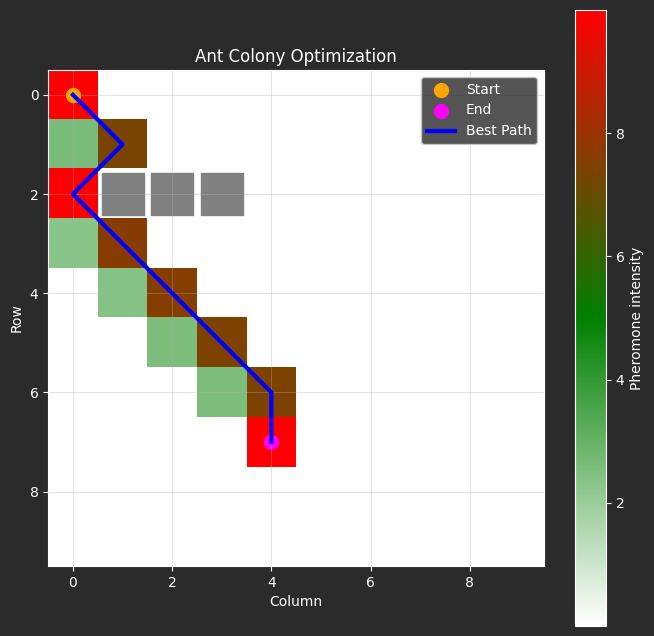

Mejor camino encontrado: [(0, 0), (1, 1), (0, 2), (1, 3), (2, 4), (3, 5), (4, 6), (4, 7)]
Longitud del camino: 8


In [12]:
def run_study_case(case_number, start, end, obstacles, iterations=100, **kwargs):
    print(f"--- Caso de Estudio {case_number} ---")
    aco = AntColonyOptimization(start, end, obstacles, **kwargs)
    aco.find_best_path(iterations)
    aco.plot()
    if aco.best_path:
        print("Mejor camino encontrado:", aco.best_path)
        print("Longitud del camino:", len(aco.best_path))
    else:
        print("No se encontró un camino válido.")

# Ejecución del Caso 1 solicitado
run_study_case(1, (0, 0), (4, 7), [(1, 2), (2, 2), (3, 2)])


### B. ¿Qué ocurre con el segundo caso de estudio?

#### Análisis del problema en el Caso 2
En el segundo caso de estudio, se observa que el algoritmo original falla al encontrar o representar el camino correcto. Esto se debe a dos razones principales:

1. **Selección de camino inválido:** El código original seleccionaba el camino más corto de cada iteración sin verificar si la hormiga realmente llegó al destino (`end`). En el Caso 2, hay una barrera que bloquea el camino directo. Muchas hormigas mueren en "callejones sin salida" creados por la barrera. Como estos caminos incompletos son más cortos que un camino que rodea la barrera, el algoritmo los elegía erróneamente como "mejores" y reforzaba con feromonas una ruta que no lleva a ninguna parte.
2. **Parámetros Greedy:** El valor de `beta=15` hace que las hormigas sean extremadamente atraídas hacia el objetivo. Esto causa que choquen contra la barrera repetidamente en lugar de explorar rutas alternativas que se alejen momentáneamente del destino para rodear el obstáculo.

#### Solución implementada
- Se modificó `find_best_path` para filtrar únicamente los caminos que terminan en la posición `end`.
- Se añadieron parámetros configurables a `run_study_case` para permitir ajustes en la exploración.

#### Ejecución del Caso de Estudio 2 (Corregido)


--- Caso de Estudio 2 ---


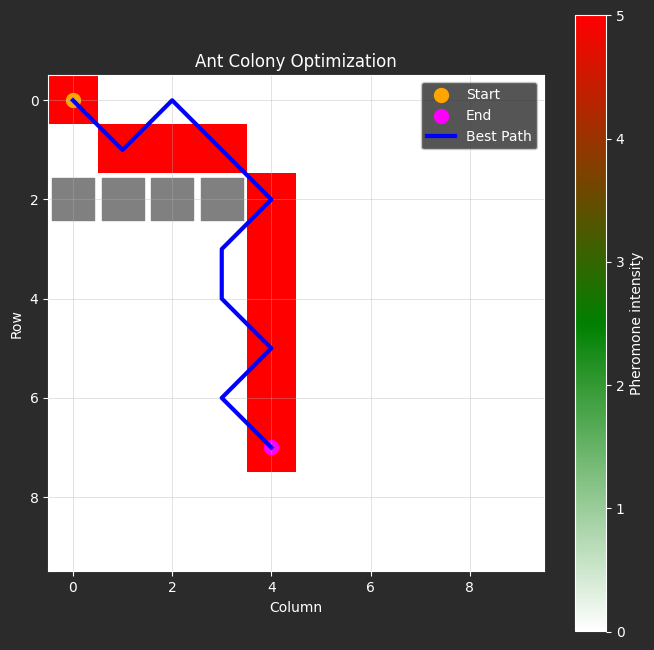

Mejor camino encontrado: [(0, 0), (1, 1), (2, 0), (3, 1), (4, 2), (3, 3), (3, 4), (4, 5), (3, 6), (4, 7)]
Longitud del camino: 10


In [13]:
# Ejecución del Caso 2 con parámetros optimizados
# Se reduce Beta para fomentar la exploración y se aumenta Alpha para dar más peso a la experiencia previa (feromona)
run_study_case(
    case_number=2, 
    start=(0, 0), 
    end=(4, 7), 
    obstacles=[(0, 2), (1, 2), (2, 2), (3, 2)],
    iterations=150,
    num_ants=20,
    evaporation_rate=0.2,
    alpha=1.0,
    beta=5.0
)


### C. Describir los parámetros del modelo

En el algoritmo de Optimización de Colonia de Hormigas (ACO), el comportamiento de búsqueda y la convergencia están regidos por varios hiperparámetros clave. A continuación se describe el propósito de cada uno:

1. **Alpha ($\alpha$):** 
   - **Propósito:** Controla la importancia de la **intensidad de la feromona**. 
   - **Efecto:** Un valor alto hace que las hormigas sigan con mayor fidelidad los caminos ya recorridos por otras hormigas (aprendizaje social/colectivo). Si es demasiado alto, el algoritmo puede converger muy rápido a soluciones subóptimas.

2. **Beta ($\beta$):** 
   - **Propósito:** Controla la importancia de la **información heurística** (en este caso, la cercanía al objetivo). 
   - **Efecto:** Representa la "visibilidad" o el deseo de avanzar directamente hacia la meta. Un valor alto hace que el algoritmo sea más "codicioso" (greedy). Como se vio en el Caso 2, un $\beta$ muy alto puede impedir que las hormigas exploren rutas laterales para rodear obstáculos.

3. **Tasa de Evaporación (`evaporation_rate` - $\rho$):** 
   - **Propósito:** Determina qué tan rápido se disipa el rastro de feromona en cada iteración. 
   - **Efecto:** Es crucial para el mecanismo de **olvido**. Permite que los caminos que no son reforzados con frecuencia desaparezcan, evitando que el sistema se estanque en rutas mediocres y permitiendo la exploración de nuevas opciones.

4. **Número de Hormigas (`num_ants`):** 
   - **Propósito:** Define cuántos agentes exploran el entorno simultáneamente en cada iteración. 
   - **Efecto:** A mayor número de hormigas, hay una mayor probabilidad de encontrar caminos válidos en entornos complejos, pero aumenta el costo computacional.

5. **Número de Iteraciones:** 
   - **Propósito:** Define cuántas veces se repite el proceso de exploración, evaporación y depósito. 
   - **Efecto:** Permite que la colonia refine gradualmente la solución a través de la retroalimentación positiva de las feromonas.


### D. ¿Qué es Random Search y Grid Search? ¿Cómo aplicarlos para esta heurística?

#### Definiciones
1. **Grid Search (Búsqueda en Rejilla):**
   - Es un método exhaustivo que prueba todas las combinaciones posibles de un conjunto predefinido de valores para cada hiperparámetro.
   - **Ventaja:** Si el espacio de búsqueda es pequeño, garantiza encontrar la mejor combinación dentro de los valores probados.
   - **Desventaja:** Sufre de la "maldición de la dimensionalidad"; el número de ejecuciones crece exponencialmente con cada nuevo parámetro.

2. **Random Search (Búsqueda Aleatoria):**
   - Selecciona combinaciones de parámetros al azar de un rango o distribución definida.
   - **Ventaja:** Suele ser más eficiente que Grid Search en espacios de alta dimensionalidad, ya que no desperdicia recursos en dimensiones que podrían no afectar significativamente el resultado.
   - **Desventaja:** No garantiza encontrar la combinación óptima, aunque con suficientes iteraciones suele acercarse mucho.

#### Aplicación en ACO
En este ejercicio de ACO, podríamos optimizar parámetros como `alpha`, `beta`, `evaporation_rate` y `num_ants`. Dado que el algoritmo tiene componentes estocásticos (aleatorios), una sola ejecución puede no ser representativa, por lo que a menudo se promedian varios resultados para cada combinación de parámetros.

#### ¿Qué búsqueda es más adecuada para este ejercicio?
Para este taller, **Grid Search** es bastante adecuado porque:
- Tenemos pocos hiperparámetros críticos (`alpha`, `beta`).
- Los rangos de valores típicos son pequeños y conocidos (ej. `alpha` entre 0.1 y 2, `beta` entre 1 y 10).
- Permite visualizar claramente cómo varía el rendimiento (longitud del camino) al cambiar sistemáticamente cada parámetro.

#### Implementación de Grid Search
A continuación, implementaremos una búsqueda simplificada para encontrar la mejor combinación de `alpha` y `beta` para el Caso de Estudio 2.


Alpha      | Beta       | Longitud  
-----------------------------------
0.10       | 1.00       | 10        
0.10       | 5.00       | 10        
0.10       | 10.00      | 10        
0.50       | 1.00       | 10        
0.50       | 5.00       | 10        
0.50       | 10.00      | 10        
1.00       | 1.00       | 10        
1.00       | 5.00       | 10        
1.00       | 10.00      | 10        
-----------------------------------
Mejor configuración: Alpha=0.1, Beta=1.0 con longitud 10

--- Visualización de la Mejor Configuración Encontrada ---
--- Caso de Estudio 2 ---


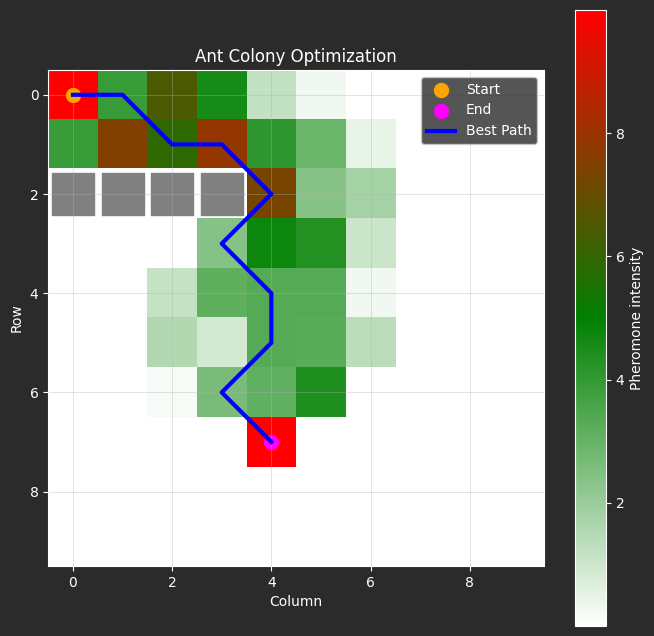

Mejor camino encontrado: [(0, 0), (1, 0), (2, 1), (3, 1), (4, 2), (3, 3), (4, 4), (4, 5), (3, 6), (4, 7)]
Longitud del camino: 10


In [14]:
import itertools

def grid_search_aco(start, end, obstacles, alpha_values, beta_values, iterations=100):
    best_overall_path = None
    best_params = None
    min_length = float('inf')
    
    print(f"{'Alpha':<10} | {'Beta':<10} | {'Longitud':<10}")
    print("-" * 35)
    
    for alpha, beta in itertools.product(alpha_values, beta_values):
        aco = AntColonyOptimization(start, end, obstacles, alpha=alpha, beta=beta, num_ants=20)
        aco.find_best_path(iterations)
        
        if aco.best_path:
            length = len(aco.best_path)
            print(f"{alpha:<10.2f} | {beta:<10.2f} | {length:<10}")
            
            if length < min_length:
                min_length = length
                best_params = (alpha, beta)
                best_overall_path = aco.best_path
        else:
            print(f"{alpha:<10.2f} | {beta:<10.2f} | No path")
            
    print("-" * 35)
    print(f"Mejor configuración: Alpha={best_params[0]}, Beta={best_params[1]} con longitud {min_length}")
    return best_params

# Definir rangos de búsqueda
alphas = [0.1, 0.5, 1.0]
betas = [1.0, 5.0, 10.0]

# Ejecutar búsqueda para el Caso 2
best_alpha, best_beta = grid_search_aco(
    start=(0, 0), 
    end=(4, 7), 
    obstacles=[(0, 2), (1, 2), (2, 2), (3, 2)],
    alpha_values=alphas,
    beta_values=betas,
    iterations=100
)

# Visualizar el mejor resultado encontrado por la búsqueda
print("\n--- Visualización de la Mejor Configuración Encontrada ---")
run_study_case(
    2, (0, 0), (4, 7), [(0, 2), (1, 2), (2, 2), (3, 2)],
    iterations=150, alpha=best_alpha, beta=best_beta, num_ants=20
)


### E. Pregunta de investigación: ¿Se puede usar ACO para el TSP?

**Respuesta:** Sí, de hecho, el Problema del Vendedor Viajero (TSP) fue la primera aplicación práctica para la cual se diseñó el algoritmo de Optimización de Colonia de Hormigas (originalmente llamado *Ant System* por Marco Dorigo en 1991).

#### Pasos para su implementación:

1. **Representación del Problema:**
   - El entorno se modela como un **grafo completo** donde cada ciudad es un nodo y cada arista entre ciudades tiene un peso que representa la distancia física o el costo de viaje.

2. **Inicialización de Feromonas:**
   - Se coloca una cantidad inicial pequeña de feromona en todas las aristas que conectan a todas las ciudades.

3. **Construcción de la Ruta (Tour):**
   - Cada hormiga se coloca en una ciudad inicial aleatoria.
   - Para visitar las demás ciudades, cada hormiga mantiene una **lista tabú** (memoria local) para asegurar que visita cada ciudad exactamente una vez y finalmente regresa a la ciudad de origen.
   - La elección de la siguiente ciudad se basa en una regla de transición probabilística que pondera la intensidad de la feromona ($\tau$) y la visibilidad ($\eta = 1/distancia$).

4. **Actualización de Feromonas:**
   - **Evaporación:** Se reduce la intensidad de la feromona en todas las aristas según una tasa definida.
   - **Depósito:** Las hormigas que completaron un tour válido depositan feromonas en las aristas recorridas. La cantidad depositada es inversamente proporcional a la longitud total del tour: $\Delta\tau = Q / L$, donde $L$ es la longitud del tour.

5. **Iteración:**
   - El ciclo de construcción y actualización se repite. Con el tiempo, las aristas que pertenecen a los tours más cortos acumulan más feromona, atrayendo a más hormigas en iteraciones posteriores.

6. **Refinamiento (Opcional):**
   - A menudo se aplican algoritmos de búsqueda local (como el intercambio 2-opt) a los tours individuales de las hormigas para acelerar la convergencia hacia el óptimo global.
